In [19]:
import os
import random
import math

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

device: mps
dataset size: 8820
label
1    5294
0    3526
Name: count, dtype: int64
   patch_id  label      type
0      3975      1  positive
1       348      1  positive
2      1804      1  positive
3      4968      1  positive
4      1810      1  positive
dataset after conservative filter:
label
1    5294
0    3526
Name: count, dtype: int64
label
1    0.600227
0    0.399773
Name: proportion, dtype: float64
train/val/test: 6174 1323 1323
train label counts:
 label
1    3706
0    2468
Name: count, dtype: int64
val label counts:
 label
1    794
0    529
Name: count, dtype: int64
test label counts:
 label
1    794
0    529
Name: count, dtype: int64

[PLAN AUGMENTATION]
train originals: 6174
P originals: 3706
N originals: 2468
target total: 12348
target pos: 7409
target neg: 4939
aug_pos_needed: 3703
aug_neg_needed: 2471

[TRAIN FINAL]
label
1    7409
0    4939
Name: count, dtype: int64
label
1    0.600016
0    0.399984
Name: proportion, dtype: float64
train/val/test: 12348 1323 1323


/Users/zahra/Files/M1-MIND/mt311/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Epoch 0 | Train Loss 0.6180 | Train Acc 0.6685 | Val Loss 0.5877 | Val Acc 0.6969 | Val AUC 0.7080
Epoch 1 | Train Loss 0.5863 | Train Acc 0.6923 | Val Loss 0.5703 | Val Acc 0.7249 | Val AUC 0.7460
Epoch 2 | Train Loss 0.5705 | Train Acc 0.7029 | Val Loss 0.5710 | Val Acc 0.7218 | Val AUC 0.7452
Epoch 3 | Train Loss 0.5613 | Train Acc 0.7110 | Val Loss 0.5467 | Val Acc 0.7294 | Val AUC 0.7631
Epoch 4 | Train Loss 0.5482 | Train Acc 0.7205 | Val Loss 0.5391 | Val Acc 0.7377 | Val AUC 0.7830
Epoch 5 | Train Loss 0.5349 | Train Acc 0.7294 | Val Loss 0.5203 | Val Acc 0.7445 | Val AUC 0.7968
Epoch 6 | Train Loss 0.5148 | Train Acc 0.7383 | Val Loss 0.5018 | Val Acc 0.7672 | Val AUC 0.8065
Epoch 7 | Train Loss 0.4951 | Train Acc 0.7553 | Val Loss 0.4823 | Val Acc 0.7649 | Val AUC 0.8258
Epoch 8 | Train Loss 0.4791 | Train Acc 0.7627 | Val Loss 0.4795 | Val Acc 0.7634 | Val AUC 0.8312
Epoch 9 | Train Loss 0.4590 | Train Acc 0.7775 | Val Loss 0.4597 | Val Acc 0.7763 | Val AUC 0.8496

TEST RESU

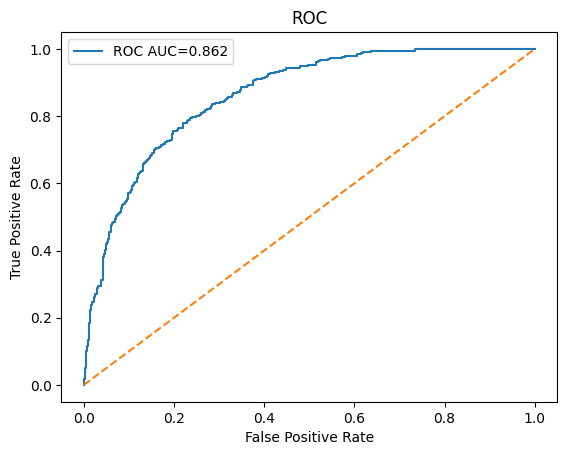

In [20]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PATCH_SIZE = 224

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)


root_dir = "./patches_dataset/patches_v2_seed42" #----------------------------
pos_dir = os.path.join(root_dir, "positive")
neg_dir = os.path.join(root_dir, "negative")

# a supp prc metadata etait gen dans le mauvais dossier...recup from metadata mtnt
def build_df_from_folders(pos_dir, neg_dir):
    rows = []

    # positifs
    for fname in os.listdir(pos_dir):
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            patch_id = int(os.path.splitext(fname)[0])
            rows.append({
                "patch_id": patch_id,
                "label": 1,
                "type": "positive",
            })

    # négatifs
    for fname in os.listdir(neg_dir):
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            patch_id = int(os.path.splitext(fname)[0])
            rows.append({
                "patch_id": patch_id,
                "label": 0,
                "type": "negative",
            })

    df = pd.DataFrame(rows)
    return df

df = build_df_from_folders(pos_dir, neg_dir)

# sécurité + types (comme ton code original)
df["patch_id"] = df["patch_id"].astype(int)
df["label"] = df["label"].astype(int)
df["type"] = df["type"].astype(str)

print("dataset size:", len(df))
print(df["label"].value_counts())
print(df.head())

# -----------------------------------------------------------------------------
# PARAMETRES EXPERIMENTAUX
# -----------------------------------------------------------------------------

USE_CONSERVATIVE_NEGATIVES = False

# Si metadata.csv contient deja ces colonnes, on peut filtrer les negatifs
# "is_conservative_negative" prioritaire
# sinon fallback possible avec "max_iou_tree_box" et "min_dist_to_tree_box"
CONSERVATIVE_MIN_DIST = 56

TARGET_MULTIPLIER = 2.0     # x2 dataset train
TARGET_POS_RATIO = 0.60     # 0.70 : 70/30 minimum => 70% positifs

THRESHOLD = 0.5             # seuil de classification
batch_size = 32
epochs = 10

# -----------------------------------------------------------------------------
# FILTRAGE NEGATIFS CONSERVATIFS
# -----------------------------------------------------------------------------

def keep_conservative_negatives(df):
    df_pos = df[df["label"] == 1].copy()
    df_neg = df[df["label"] == 0].copy()

    if not USE_CONSERVATIVE_NEGATIVES:
        out = pd.concat([df_pos, df_neg], ignore_index=True)
        return out.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    if "is_conservative_negative" in df.columns:
        df_neg = df_neg[df_neg["is_conservative_negative"].astype(int) == 1].copy()
        print(f"[INFO] conservative negatives via is_conservative_negative: {len(df_neg)}")
    elif {"max_iou_tree_box", "min_dist_to_tree_box"}.issubset(df.columns):
        df_neg = df_neg[
            (df_neg["max_iou_tree_box"] <= 0.0) &
            (df_neg["min_dist_to_tree_box"] >= CONSERVATIVE_MIN_DIST)
        ].copy()
        print(f"[INFO] conservative negatives via IoU/dist filtering: {len(df_neg)}")
    else:
        print("[WARN] no conservative negative columns found in metadata.csv -> using all negatives")

    out = pd.concat([df_pos, df_neg], ignore_index=True)
    return out.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


df = keep_conservative_negatives(df)

print("dataset after conservative filter:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))

# -----------------------------------------------------------------------------
# SPLIT STRATIFIE : train / val / test
# -----------------------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

print("train/val/test:", len(train_df), len(val_df), len(test_df))
print("train label counts:\n", train_df["label"].value_counts())
print("val label counts:\n", val_df["label"].value_counts())
print("test label counts:\n", test_df["label"].value_counts())

# -----------------------------------------------------------------------------
# CONSTRUCTION D'UN TRAIN X2 AVEC RATIO 60/40 (def plus haut)
# -----------------------------------------------------------------------------

def build_x2_ratio_train_df(train_df, multiplier=2.0, target_pos_ratio=0.70):
    train_pos = train_df[train_df["label"] == 1].copy()
    train_neg = train_df[train_df["label"] == 0].copy()

    P = len(train_pos)
    N = len(train_neg)

    T = int(round(multiplier * (P + N)))
    target_pos = int(round(target_pos_ratio * T))
    target_neg = T - target_pos

    aug_pos_needed = max(0, target_pos - P)
    aug_neg_needed = max(0, target_neg - N)

    print("\n[PLAN AUGMENTATION]")
    print("train originals:", P + N)
    print("P originals:", P)
    print("N originals:", N)
    print("target total:", T)
    print("target pos:", target_pos)
    print("target neg:", target_neg)
    print("aug_pos_needed:", aug_pos_needed)
    print("aug_neg_needed:", aug_neg_needed)

    train_pos["augmented"] = 0
    train_neg["augmented"] = 0

    aug_parts = [train_pos, train_neg]

    if aug_pos_needed > 0:
        aug_pos_df = train_pos.sample(
            n=aug_pos_needed,
            replace=True,
            random_state=SEED
        ).copy()
        aug_pos_df["augmented"] = 1
        aug_parts.append(aug_pos_df)

    if aug_neg_needed > 0:
        aug_neg_df = train_neg.sample(
            n=aug_neg_needed,
            replace=True,
            random_state=SEED
        ).copy()
        aug_neg_df["augmented"] = 1
        aug_parts.append(aug_neg_df)

    train_df_final = pd.concat(aug_parts, ignore_index=True)
    train_df_final = train_df_final.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    print("\n[TRAIN FINAL]")
    print(train_df_final["label"].value_counts())
    print(train_df_final["label"].value_counts(normalize=True))

    return train_df_final


train_df = build_x2_ratio_train_df(
    train_df,
    multiplier=TARGET_MULTIPLIER,
    target_pos_ratio=TARGET_POS_RATIO
)

val_df = val_df.copy()
val_df["augmented"] = 0

test_df = test_df.copy()
test_df["augmented"] = 0

# -----------------------------------------------------------------------------
# TRANSFORMS
# -----------------------------------------------------------------------------

train_transform_plain = A.Compose([
    A.Resize(PATCH_SIZE, PATCH_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# plus forte augmentation sur les positifs car on veut pousser vers 70/30
train_transform_aug_pos = A.Compose([
    A.Resize(PATCH_SIZE, PATCH_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.08,
        rotate_limit=20,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.5
    ),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# augmentation plus moderee sur les negatifs
train_transform_aug_neg = A.Compose([
    A.Resize(PATCH_SIZE, PATCH_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.02,
        scale_limit=0.06,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.6
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.10,
        contrast_limit=0.10,
        p=0.4
    ),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(PATCH_SIZE, PATCH_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# -----------------------------------------------------------------------------
# DATASET
# -----------------------------------------------------------------------------

class PatchDataset(Dataset):
    def __init__(self, df, root_dir, transform=None,
                 transform_plain=None, transform_aug_pos=None, transform_aug_neg=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.transform_plain = transform_plain
        self.transform_aug_pos = transform_aug_pos
        self.transform_aug_neg = transform_aug_neg

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patch_id = int(row["patch_id"])
        label = int(row["label"])
        t = row["type"].strip().lower()

        augmented = 0
        if "augmented" in row.index:
            augmented = int(row["augmented"])

        subdir = "positive" if t == "positive" else "negative"
        img_path = os.path.join(self.root_dir, subdir, f"{patch_id}.png")
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing patch file: {img_path}")

        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Could not read image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # comportement original si un seul transform est fourni
        if self.transform is not None:
            img = self.transform(image=img)["image"]
        else:
            # nouveau mode : plain / aug_pos / aug_neg
            if augmented == 0:
                img = self.transform_plain(image=img)["image"]
            else:
                if label == 1:
                    img = self.transform_aug_pos(image=img)["image"]
                else:
                    img = self.transform_aug_neg(image=img)["image"]

        y = torch.tensor(label, dtype=torch.float32)
        return img, y


train_dataset = PatchDataset(
    train_df,
    root_dir=root_dir,
    transform=None,
    transform_plain=train_transform_plain,
    transform_aug_pos=train_transform_aug_pos,
    transform_aug_neg=train_transform_aug_neg,
)

val_dataset = PatchDataset(
    val_df,
    root_dir=root_dir,
    transform=eval_transform
)

test_dataset = PatchDataset(
    test_df,
    root_dir=root_dir,
    transform=eval_transform
)

print("train/val/test:", len(train_dataset), len(val_dataset), len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

# -----------------------------------------------------------------------------
# MODELE
# -----------------------------------------------------------------------------

class SimpleCNN3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # 3 bc RGB
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # archi 16/32/64
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.head = nn.Linear(64, 1) # couche classif finale FC, classif binaire donc 1 score suffit

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x) # pour non linéarité sans vanishing gradient
        x = self.pool(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = F.relu(x)
        x = self.pool(x)

        x = x.mean(dim=(2, 3)) # global avg pooling : moyenner chaque feature map en un chiffre

        x = self.head(x) # [batch_size,1] devient...
        logits = x.squeeze(1) # [batch_size] (vect)
        return logits


model = SimpleCNN3().to(device)

# Comme on impose deja un ratio 70/30 dans le train,
# je conseille de commencer sans pos_weight
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------------------------------------------------------
# TRAIN / EVAL
# -----------------------------------------------------------------------------

def train_one_epoch():
    model.train() # start training
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader: # load batches
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad() # gradients remis à 0
        logits = model(x) # fwd pass
        loss = criterion(logits, y) # calcule erreur
        loss.backward() # calcule gradients
        optimizer.step() # maj poids avec gradients

        total_loss += loss.item() * x.size(0) # pour moyenner sur epoch apres

        probs = torch.sigmoid(logits)
        preds = (probs >= THRESHOLD).float()
        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def evaluate_scores(loader):
    model.eval()
    all_scores = []
    all_labels = []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_scores.append(probs)
        all_labels.append(y.numpy())

    scores = np.concatenate(all_scores, axis=0).astype(np.float64)
    labels = np.concatenate(all_labels, axis=0).astype(np.int32)
    return scores, labels


@torch.no_grad()
def evaluate_loss_acc(loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= THRESHOLD).float()
        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)


# -----------------------------------------------------------------------------
# TRAINING LOOP AVEC SELECTION SUR VAL AUC
# -----------------------------------------------------------------------------

best_val_auc = -1.0
best_state_dict = None

for epoch in range(epochs):
    loss, acc = train_one_epoch()

    val_loss, val_acc = evaluate_loss_acc(val_loader)
    val_scores, val_labels = evaluate_scores(val_loader)

    fpr_val, tpr_val, _ = roc_curve(val_labels, val_scores)
    val_auc = auc(fpr_val, tpr_val)

    print(
        f"Epoch {epoch} | "
        f"Train Loss {loss:.4f} | Train Acc {acc:.4f} | "
        f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f} | Val AUC {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

# remettre meilleur modele
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

# -----------------------------------------------------------------------------
# EVALUATION TEST
# -----------------------------------------------------------------------------

scores, labels = evaluate_scores(test_loader)

fpr, tpr, _ = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

preds = (scores >= THRESHOLD).astype(np.int32)

print("\nTEST RESULTS")
print("ROC AUC:", roc_auc)
print("Confusion matrix:\n", confusion_matrix(labels, preds))
print(classification_report(labels, preds, digits=4))

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

for threshold in [0.5, 0.6, 0.7]:
    preds = (scores >= threshold).astype(np.int32)

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    cm = confusion_matrix(labels, preds)

    print("\n" + "="*60)
    print(f"THRESHOLD = {threshold}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print("Confusion matrix:")
    print(cm)
    print("\nClassification report:")
    print(classification_report(labels, preds, digits=4))


THRESHOLD = 0.5
Accuracy  : 0.7884
Precision : 0.7961
Recall    : 0.8703
F1-score  : 0.8315
Confusion matrix:
[[352 177]
 [103 691]]

Classification report:
              precision    recall  f1-score   support

           0     0.7736    0.6654    0.7154       529
           1     0.7961    0.8703    0.8315       794

    accuracy                         0.7884      1323
   macro avg     0.7849    0.7678    0.7735      1323
weighted avg     0.7871    0.7884    0.7851      1323


THRESHOLD = 0.6
Accuracy  : 0.7717
Precision : 0.8484
Recall    : 0.7544
F1-score  : 0.7987
Confusion matrix:
[[422 107]
 [195 599]]

Classification report:
              precision    recall  f1-score   support

           0     0.6840    0.7977    0.7365       529
           1     0.8484    0.7544    0.7987       794

    accuracy                         0.7717      1323
   macro avg     0.7662    0.7761    0.7676      1323
weighted avg     0.7827    0.7717    0.7738      1323


THRESHOLD = 0.7
Accuracy  : 0

dataset after conservative filter:
label
1    5294
0    3526
Name: count, dtype: int64
label
1    0.600227
0    0.399773
Name: proportion, dtype: float64
train/val/test: 6174 1323 1323
train label counts:
 label
1    3706
0    2468
Name: count, dtype: int64
val label counts:
 label
1    794
0    529
Name: count, dtype: int64
test label counts:
 label
1    794
0    529
Name: count, dtype: int64

[PLAN AUGMENTATION]
train originals: 6174
P originals: 3706
N originals: 2468
target total: 12348
target pos: 8644
target neg: 3704
aug_pos_needed: 4938
aug_neg_needed: 1236

[TRAIN FINAL]
label
1    8644
0    3704
Name: count, dtype: int64
label
1    0.700032
0    0.299968
Name: proportion, dtype: float64
train/val/test: 12348 1323 1323


/Users/zahra/Files/M1-MIND/mt311/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Epoch 0 | Train Loss 0.5587 | Train Acc 0.7438 | Val Loss 0.6014 | Val Acc 0.6810 | Val AUC 0.6734
Epoch 1 | Train Loss 0.5257 | Train Acc 0.7634 | Val Loss 0.6186 | Val Acc 0.6878 | Val AUC 0.6812
Epoch 2 | Train Loss 0.5066 | Train Acc 0.7704 | Val Loss 0.6097 | Val Acc 0.6931 | Val AUC 0.7302
Epoch 3 | Train Loss 0.4958 | Train Acc 0.7810 | Val Loss 0.5759 | Val Acc 0.6969 | Val AUC 0.7427
Epoch 4 | Train Loss 0.4780 | Train Acc 0.7880 | Val Loss 0.5668 | Val Acc 0.7188 | Val AUC 0.7577
Epoch 5 | Train Loss 0.4672 | Train Acc 0.7910 | Val Loss 0.5410 | Val Acc 0.7241 | Val AUC 0.7792
Epoch 6 | Train Loss 0.4599 | Train Acc 0.7943 | Val Loss 0.5392 | Val Acc 0.7362 | Val AUC 0.7842
Epoch 7 | Train Loss 0.4473 | Train Acc 0.7984 | Val Loss 0.5346 | Val Acc 0.7407 | Val AUC 0.8031
Epoch 8 | Train Loss 0.4375 | Train Acc 0.8024 | Val Loss 0.5564 | Val Acc 0.7317 | Val AUC 0.8133
Epoch 9 | Train Loss 0.4258 | Train Acc 0.8085 | Val Loss 0.5007 | Val Acc 0.7528 | Val AUC 0.8096

TEST RESU

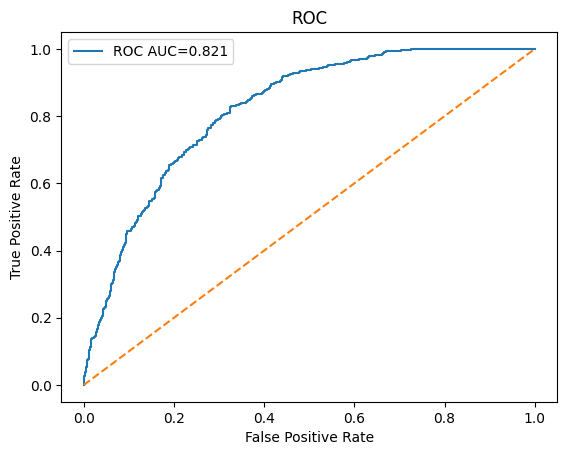

In [22]:
# -----------------------------------------------------------------------------
# PARAMETRES EXPERIMENTAUX
# -----------------------------------------------------------------------------

USE_CONSERVATIVE_NEGATIVES = False

# Si metadata.csv contient deja ces colonnes, on peut filtrer les negatifs
# "is_conservative_negative" prioritaire
# sinon fallback possible avec "max_iou_tree_box" et "min_dist_to_tree_box"
CONSERVATIVE_MIN_DIST = 56

TARGET_MULTIPLIER = 2.0     # x2 dataset train
TARGET_POS_RATIO = 0.70     # 0.70 : 70/30 minimum => 70% positifs

THRESHOLD = 0.5             # seuil de classification
batch_size = 32
epochs = 10

# -----------------------------------------------------------------------------
# FILTRAGE NEGATIFS CONSERVATIFS
# -----------------------------------------------------------------------------
df = keep_conservative_negatives(df)

print("dataset after conservative filter:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))

# -----------------------------------------------------------------------------
# SPLIT STRATIFIE : train / val / test
# -----------------------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

print("train/val/test:", len(train_df), len(val_df), len(test_df))
print("train label counts:\n", train_df["label"].value_counts())
print("val label counts:\n", val_df["label"].value_counts())
print("test label counts:\n", test_df["label"].value_counts())

# -----------------------------------------------------------------------------
# CONSTRUCTION D'UN TRAIN X2 AVEC RATIO 70/30
# -----------------------------------------------------------------------------
train_df = build_x2_ratio_train_df(
    train_df,
    multiplier=TARGET_MULTIPLIER,
    target_pos_ratio=TARGET_POS_RATIO
)

val_df = val_df.copy()
val_df["augmented"] = 0

test_df = test_df.copy()
test_df["augmented"] = 0

# -----------------------------------------------------------------------------
# TRANSFORMS
# -----------------------------------------------------------------------------

train_transform_plain = A.Compose([
    A.Resize(PATCH_SIZE, PATCH_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# plus forte augmentation sur les positifs car on veut pousser vers 70/30
train_transform_aug_pos = A.Compose([
    A.Resize(PATCH_SIZE, PATCH_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.08,
        rotate_limit=20,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.5
    ),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# augmentation plus moderee sur les negatifs
train_transform_aug_neg = A.Compose([
    A.Resize(PATCH_SIZE, PATCH_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.02,
        scale_limit=0.06,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.6
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.10,
        contrast_limit=0.10,
        p=0.4
    ),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(PATCH_SIZE, PATCH_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# -----------------------------------------------------------------------------
# DATASET
# -----------------------------------------------------------------------------

class PatchDataset(Dataset):
    def __init__(self, df, root_dir, transform=None,
                 transform_plain=None, transform_aug_pos=None, transform_aug_neg=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.transform_plain = transform_plain
        self.transform_aug_pos = transform_aug_pos
        self.transform_aug_neg = transform_aug_neg

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patch_id = int(row["patch_id"])
        label = int(row["label"])
        t = row["type"].strip().lower()

        augmented = 0
        if "augmented" in row.index:
            augmented = int(row["augmented"])

        subdir = "positive" if t == "positive" else "negative"
        img_path = os.path.join(self.root_dir, subdir, f"{patch_id}.png")
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing patch file: {img_path}")

        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Could not read image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # comportement original si un seul transform est fourni
        if self.transform is not None:
            img = self.transform(image=img)["image"]
        else:
            # nouveau mode : plain / aug_pos / aug_neg
            if augmented == 0:
                img = self.transform_plain(image=img)["image"]
            else:
                if label == 1:
                    img = self.transform_aug_pos(image=img)["image"]
                else:
                    img = self.transform_aug_neg(image=img)["image"]

        y = torch.tensor(label, dtype=torch.float32)
        return img, y


train_dataset = PatchDataset(
    train_df,
    root_dir=root_dir,
    transform=None,
    transform_plain=train_transform_plain,
    transform_aug_pos=train_transform_aug_pos,
    transform_aug_neg=train_transform_aug_neg,
)

val_dataset = PatchDataset(
    val_df,
    root_dir=root_dir,
    transform=eval_transform
)

test_dataset = PatchDataset(
    test_df,
    root_dir=root_dir,
    transform=eval_transform
)

print("train/val/test:", len(train_dataset), len(val_dataset), len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

# -----------------------------------------------------------------------------
# MODELE
# -----------------------------------------------------------------------------

class SimpleCNN3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # 3 bc RGB
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # archi 16/32/64
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.head = nn.Linear(64, 1) # couche classif finale FC, classif binaire donc 1 score suffit

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x) # pour non linéarité sans vanishing gradient
        x = self.pool(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = F.relu(x)
        x = self.pool(x)

        x = x.mean(dim=(2, 3)) # global avg pooling : moyenner chaque feature map en un chiffre

        x = self.head(x) # [batch_size,1] devient...
        logits = x.squeeze(1) # [batch_size] (vect)
        return logits


model = SimpleCNN3().to(device)

# Comme on impose deja un ratio 70/30 dans le train,
# je conseille de commencer sans pos_weight
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------------------------------------------------------
# TRAIN / EVAL
# -----------------------------------------------------------------------------

def train_one_epoch():
    model.train() # start training
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader: # load batches
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad() # gradients remis à 0
        logits = model(x) # fwd pass
        loss = criterion(logits, y) # calcule erreur
        loss.backward() # calcule gradients
        optimizer.step() # maj poids avec gradients

        total_loss += loss.item() * x.size(0) # pour moyenner sur epoch apres

        probs = torch.sigmoid(logits)
        preds = (probs >= THRESHOLD).float()
        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def evaluate_scores(loader):
    model.eval()
    all_scores = []
    all_labels = []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_scores.append(probs)
        all_labels.append(y.numpy())

    scores = np.concatenate(all_scores, axis=0).astype(np.float64)
    labels = np.concatenate(all_labels, axis=0).astype(np.int32)
    return scores, labels


@torch.no_grad()
def evaluate_loss_acc(loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= THRESHOLD).float()
        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)


# -----------------------------------------------------------------------------
# TRAINING LOOP AVEC SELECTION SUR VAL AUC
# -----------------------------------------------------------------------------

best_val_auc = -1.0
best_state_dict = None

for epoch in range(epochs):
    loss, acc = train_one_epoch()

    val_loss, val_acc = evaluate_loss_acc(val_loader)
    val_scores, val_labels = evaluate_scores(val_loader)

    fpr_val, tpr_val, _ = roc_curve(val_labels, val_scores)
    val_auc = auc(fpr_val, tpr_val)

    print(
        f"Epoch {epoch} | "
        f"Train Loss {loss:.4f} | Train Acc {acc:.4f} | "
        f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f} | Val AUC {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

# remettre meilleur modele
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

# -----------------------------------------------------------------------------
# EVALUATION TEST
# -----------------------------------------------------------------------------

scores, labels = evaluate_scores(test_loader)

fpr, tpr, _ = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

preds = (scores >= THRESHOLD).astype(np.int32)

print("\nTEST RESULTS")
print("ROC AUC:", roc_auc)
print("Confusion matrix:\n", confusion_matrix(labels, preds))
print(classification_report(labels, preds, digits=4))

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.show()

In [23]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

for threshold in [0.5, 0.6, 0.7]:
    preds = (scores >= threshold).astype(np.int32)

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    cm = confusion_matrix(labels, preds)

    print("\n" + "="*60)
    print(f"THRESHOLD = {threshold}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print("Confusion matrix:")
    print(cm)
    print("\nClassification report:")
    print(classification_report(labels, preds, digits=4))


THRESHOLD = 0.5
Accuracy  : 0.7339
Precision : 0.6991
Recall    : 0.9773
F1-score  : 0.8151
Confusion matrix:
[[195 334]
 [ 18 776]]

Classification report:
              precision    recall  f1-score   support

           0     0.9155    0.3686    0.5256       529
           1     0.6991    0.9773    0.8151       794

    accuracy                         0.7339      1323
   macro avg     0.8073    0.6730    0.6704      1323
weighted avg     0.7856    0.7339    0.6994      1323


THRESHOLD = 0.6
Accuracy  : 0.7438
Precision : 0.7136
Recall    : 0.9572
F1-score  : 0.8176
Confusion matrix:
[[224 305]
 [ 34 760]]

Classification report:
              precision    recall  f1-score   support

           0     0.8682    0.4234    0.5693       529
           1     0.7136    0.9572    0.8176       794

    accuracy                         0.7438      1323
   macro avg     0.7909    0.6903    0.6934      1323
weighted avg     0.7754    0.7438    0.7183      1323


THRESHOLD = 0.7
Accuracy  : 0